<a href="https://colab.research.google.com/github/Utsav248/Utsav_Jarga_Magar_2408957_AIML/blob/main/Worksheet1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Image

In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')

image_path = '/content/drive/MyDrive/AIML/Data/Face.jpg'
if os.path.exists(image_path):
    print(f'Found image at: {image_path}')
else:
    print(f'Warning: {image_path} not found. Please check your Drive folder structure.')

Mounted at /content/drive
Found image at: /content/drive/MyDrive/AIML/Data/Face.jpg


# Exervise 1

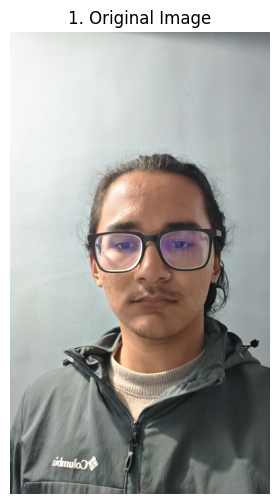

In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

# 1. Read and display the image using Pillow
image_path = '/content/drive/MyDrive/AIML/Data/Face.jpg'
img_pil = Image.open(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img_pil)
plt.title('1. Original Image')
plt.axis('off')
plt.show()

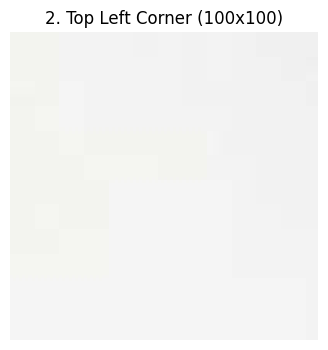

In [9]:
# 2. Display only the top left corner of 100x100 pixels
img_array = np.array(img_pil)
top_left = img_array[:100, :100]

plt.figure(figsize=(4, 4))
plt.imshow(top_left)
plt.title('2. Top Left Corner (100x100)')
plt.axis('off')
plt.show()

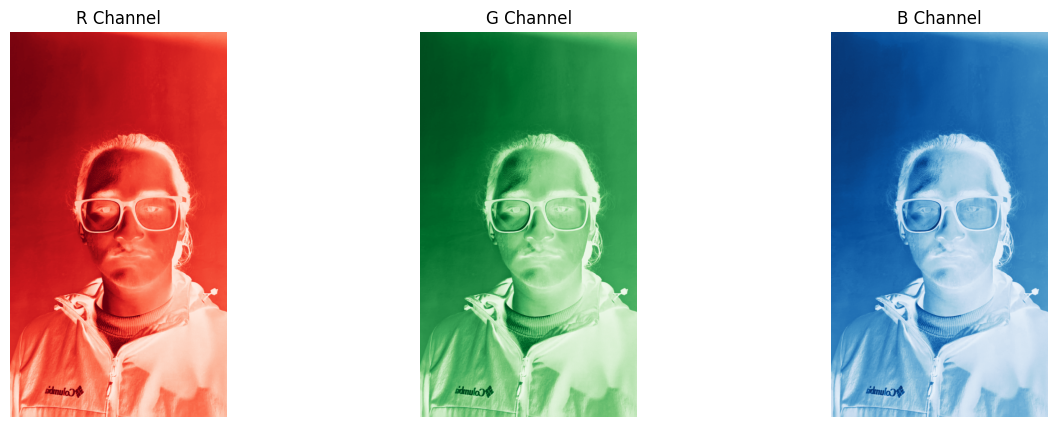

In [10]:
# 3. Show the three color channels (R, G, B) using NumPy
red_channel = img_array[:, :, 0]
green_channel = img_array[:, :, 1]
blue_channel = img_array[:, :, 2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(red_channel, cmap='Reds')
axes[0].set_title('R Channel')
axes[0].axis('off')

axes[1].imshow(green_channel, cmap='Greens')
axes[1].set_title('G Channel')
axes[1].axis('off')

axes[2].imshow(blue_channel, cmap='Blues')
axes[2].set_title('B Channel')
axes[2].axis('off')

plt.show()

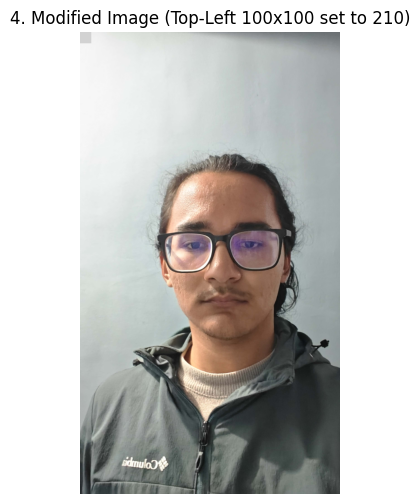

In [21]:
# 4. Modify the top 100x100 pixels to a value of 210 and display
modified_img = img_array.copy()
modified_img[:100, :100] = 210

plt.figure(figsize=(6, 6))
plt.imshow(modified_img)
plt.title('4. Modified Image (Top-Left 100x100 set to 210)')
plt.axis('off')
plt.show()

# Exercise 2

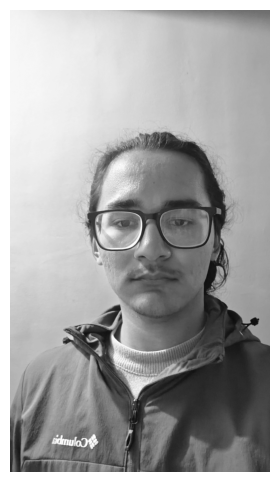

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load and display a grayscale image
image_path = '/content/drive/MyDrive/AIML/Data/Face.jpg'
img_gray = Image.open(image_path).convert('L')

plt.figure(figsize=(6, 6))
plt.imshow(img_gray, cmap='gray')
"plt.title('1. Grayscale Image')"
plt.axis('off')
plt.show()

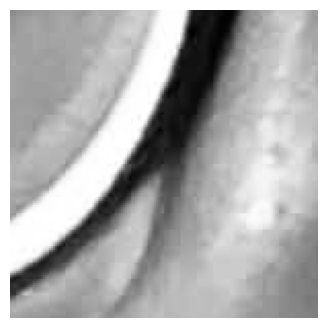

In [13]:
# 2. Extract and display the middle section (150 pixels)
gray_array = np.array(img_gray)
h, w = gray_array.shape
center_h, center_w = h // 2, w // 2
# Extract 150x150 section around center
middle_section = gray_array[center_h-75:center_h+75, center_w-75:center_w+75]

plt.figure(figsize=(4, 4))
plt.imshow(middle_section, cmap='gray')
"plt.title('2. Middle Section (150x150)')"
plt.axis('off')
plt.show()

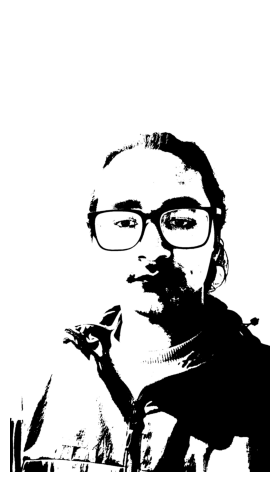

In [14]:
# 3. Apply a simple threshold (Binary Image)
binary_image = np.where(gray_array < 100, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(binary_image, cmap='gray')
"plt.title('3. Binary Threshold Image (Threshold=100)')"
plt.axis('off')
plt.show()

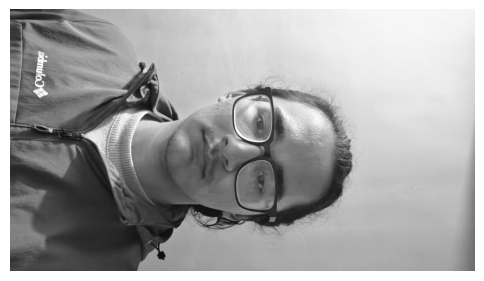

In [15]:
# 4. Rotate the image 90 degrees clockwise
# Using Pillow's rotate (note: expand=True ensures the whole image fits)
rotated_img = img_gray.rotate(-90, expand=True)

plt.figure(figsize=(6, 6))
plt.imshow(rotated_img, cmap='gray')
"plt.title('4. Rotated Image (90° Clockwise)')"
plt.axis('off')
plt.show()

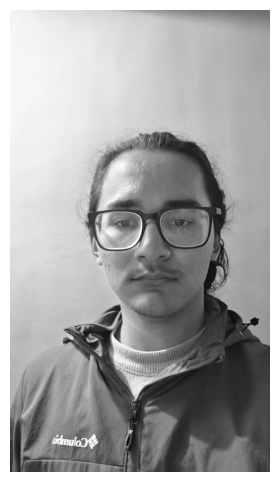

Shape of RGB replicated image: (4096, 2304, 3)


In [16]:
# 5. Convert grayscale image to an RGB image
# Stack the grayscale array three times along the last axis
rgb_replicated = np.stack((gray_array,) * 3, axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb_replicated)
"plt.title('5. Grayscale Converted to RGB')"
plt.axis('off')
plt.show()

print(f'Shape of RGB replicated image: {rgb_replicated.shape}')

# Exercise 3

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load and Prepare Data
# Using the grayscale image already loaded in previous tasks
img_arr = np.array(img_gray).astype(float)

# Center the data: Subtract the mean of each column
mean_vec = np.mean(img_arr, axis=0)
centered_data = img_arr - mean_vec

# Calculate the Covariance Matrix
# Formula: (1/n-1) * X.T * X
cov_matrix = np.cov(centered_data, rowvar=False)

print(f'Shape of data: {centered_data.shape}')
print(f'Shape of covariance matrix: {cov_matrix.shape}')

Shape of data: (4096, 2304)
Shape of covariance matrix: (2304, 2304)


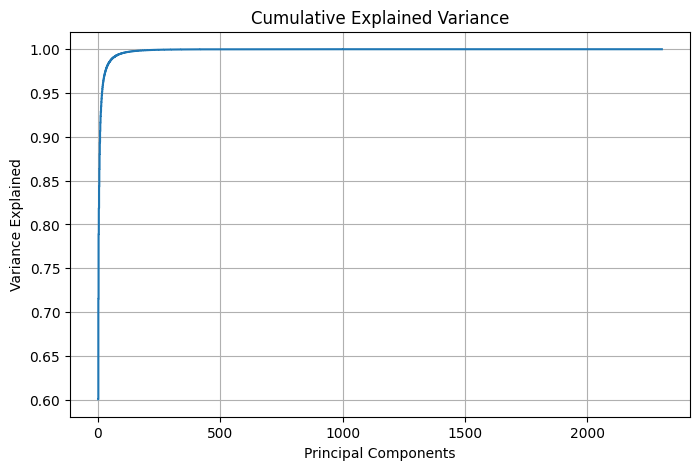

Top 10 Eigenvalues: [3955024.66032232  755371.51379563  484956.41852748  196134.401079
  162292.86434023  130974.18789945  112439.07895981   89055.60281731
   83907.41162028   63810.51449733]


In [19]:
# 2. Eigen Decomposition
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Sort in descending order
idx = np.argsort(eigen_values)[::-1]
eigen_values = eigen_values[idx]
eigen_vectors = eigen_vectors[:, idx]

# Cumulative Explained Variance
exp_var = eigen_values / np.sum(eigen_values)
cum_exp_var = np.cumsum(exp_var)

plt.figure(figsize=(8, 5))
plt.step(range(1, len(cum_exp_var)+1), cum_exp_var, where='mid')
plt.title('Cumulative Explained Variance')
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.show()

print(f'Top 10 Eigenvalues: {eigen_values[:10]}')

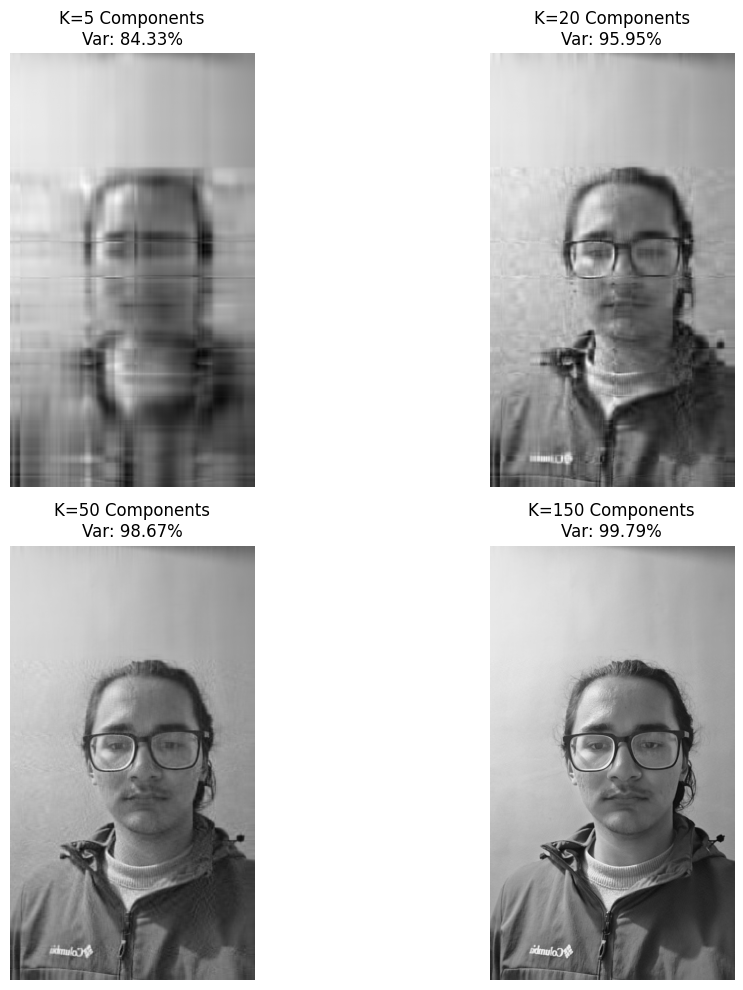

In [20]:
# 3. Reconstruction and Experiment
def reconstruct_pca(k):
    # Select top k eigenvectors
    selected_vectors = eigen_vectors[:, :k]
    # Transform (Project) to lower dimensions
    low_dim = np.dot(centered_data, selected_vectors)
    # Reconstruct back to original space
    reconstructed = np.dot(low_dim, selected_vectors.T) + mean_vec
    return reconstructed, cum_exp_var[k-1] * 100

# Experiments: Choose 4 different K values
k_values = [5, 20, 50, 150]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, k in enumerate(k_values):
    reconstructed, var = reconstruct_pca(k)
    axes[i].imshow(reconstructed, cmap='gray')
    axes[i].set_title(f'K={k} Components\nVar: {var:.2f}%')
    axes[i].axis('off')

plt.tight_layout()
plt.show()